# 01 Matrix
[Leetcode Link](https://leetcode.com/problems/01-matrix/description/)

Given an m x n binary matrix mat, return the distance of the nearest 0 for each cell.

The distance between two cells sharing a common edge is 1.

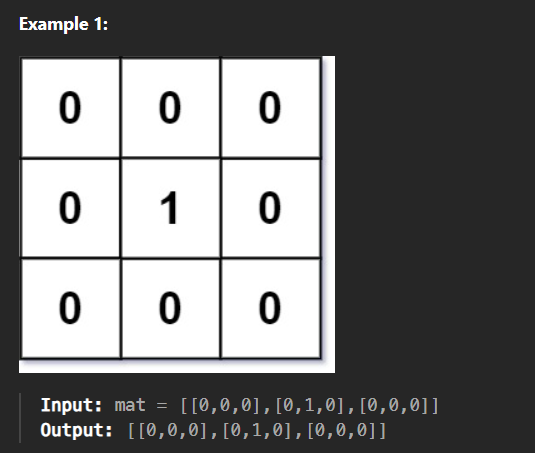

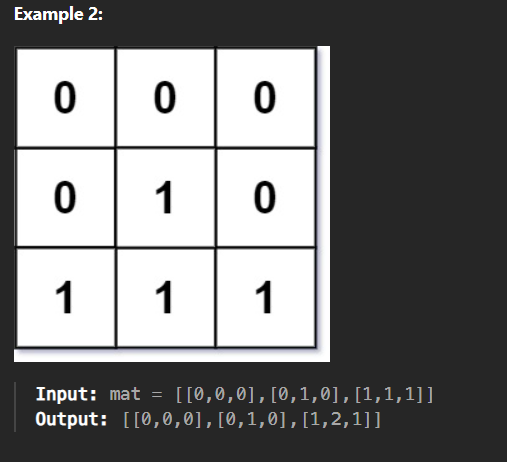

### Constraints:
* m == mat.length
* n == mat[i].length
* 1 <= m, n <= 104
* 1 <= m * n <= 104
* mat[i][j] is either 0 or 1.
* There is at least one 0 in mat.

## Approach 1: Use BFS at each `0` cell
We will create a separate 2D array `answe` to store the answer as it is typically best practice to not alter the original input. Although it'll take up more space, it'll result in less possible bugs in our algorithm because we don't have to worry about dealing with altered values. 

As we iterate through each cell in `mat`, if we encounter a cell that is `0` then we know that its value in `answer` is 0. We also know that its neighbors values are `1`. So we can do a breath-first search from these cells to get our answer. If we encounter surrounding cells that already have an assigned value in `answer`, then we pick the lowest value between the assigned value and our calculated distance from the last `0` cell.

### Complexity:
* Time: $O(m^{2} * n^{2})$ 
    * time to iterate over all the cells is O(m*n)
    * for each iterated cell, we may perform a BFS which is O(m*n)
    * So the total time complexity is $O(m*n*m*n) = O(m^{2} * n^{2})$
    * This time complexity is not ideal, and will result in some leetcode testcases timing out
* Space complexity: $O(m*n)$
    * for the `seen` set and `answer`

In [ ]:
from collections import deque

def updateMatrix(mat: List[List[int]]) -> List[List[int]]:
    neighbors= [[0,1],[0,-1],[1,0],[-1,0]]
    rows = len(mat)
    cols = len(mat[0])
    answer = [[None]*cols for i in range(rows)]

    def bfs_update(row,col):
        if mat[row][col] != 0:
            return
        seen = set()
        distance = 0
        cell_queue = deque([(row,col)])

        while cell_queue:
            layer = len(cell_queue)
            for index in range(layer):
                r_cell, c_cell = cell_queue.popleft()
                seen.add((r_cell,c_cell))
                if answer[r_cell][c_cell] == None or answer[r_cell][c_cell] > distance:
                    answer[r_cell][c_cell] = distance
                else:
                    continue
                for n in neighbors:
                    new_r = r_cell + n[0]
                    new_c = c_cell + n[1]
                    if new_r < 0 or new_r >= rows:
                        continue
                    if new_c < 0 or new_c >= cols:
                        continue
                    if (new_r,new_c) in seen:
                        continue
                    if mat[new_r][new_c] == 0:
                        continue
                    cell_queue.append((new_r, new_c))
            distance += 1


    for r in range(rows):
        for c in range(cols):
            bfs_update(r,c)
    
    return answer

## Approach 2: Do BFS from all 0 cells 
To improve the time complexity, we can simply perform BFS on all 0 cells in one iterative loop. To do that, we need to find all 0 cells in `mat` and put them in the queue `cell_queue`. Then, we iterate over `cell_queue` while `cell_queue` is not empty. For each iteration, we do a BFS, add the neighbors to `cell_queue`, and increment the distance by 1. If a cell in `cell_queue` has no assigned value in `answer`, we assign it to `distance`.

### Analysis
* Time Complexity: $O(m*n)$
    * we should end up iterating over each cell about twice with this approach:
        * once to find 0 cells
        * once or so more as we're doing the BFS
* Space Complexity: $O(m*n)$
    * for `answer`

In [ ]:
from collections import deque

def updateMatrix(mat: List[List[int]]) -> List[List[int]]:
    neighbors= [[0,1],[0,-1],[1,0],[-1,0]]
    rows = len(mat)
    cols = len(mat[0])
    answer = [[None for j in range(cols)] for i in range(rows)]
    cell_queue = deque()
    distance = 0

    def valid_cell(row,col):
        if row < 0 or row >= rows or col < 0 or col >= cols:
            return False
        return True

    for r in range(rows):
        for c in range(cols):
            if mat[r][c] == 0:
                cell_queue.append((r,c))
    
    while cell_queue:
        layer = len(cell_queue)
        for index in range(layer):
            cell = cell_queue.popleft()
            if answer[cell[0]][cell[1]] != None:
                continue
            answer[cell[0]][cell[1]] = distance
            for n in neighbors:
                new_r = cell[0] + n[0]
                new_c = cell[1] + n[1]
                if valid_cell(new_r, new_c):
                    cell_queue.append((new_r,new_c))
        distance += 1

    return answer